(15, 1101, 118, 118)


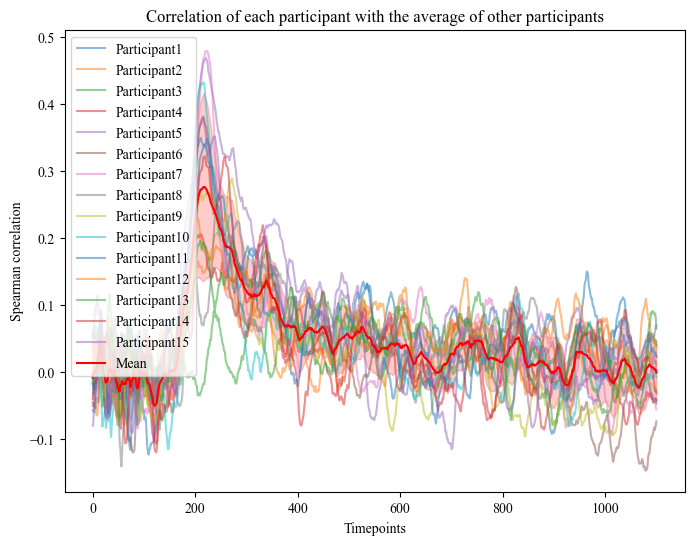

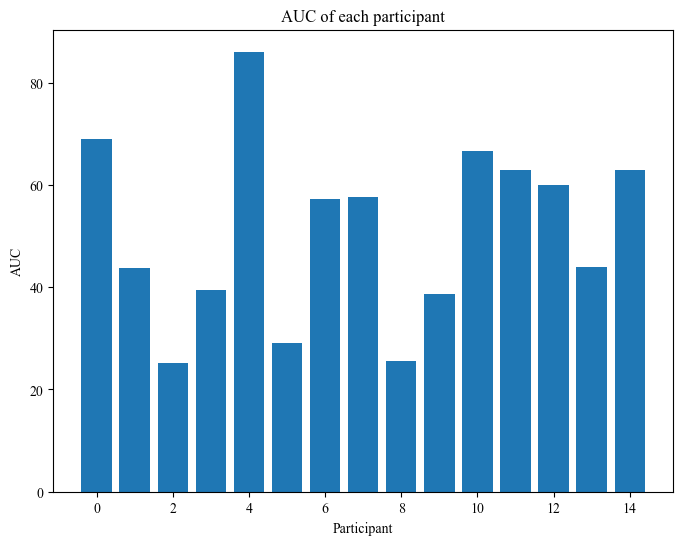

In [14]:
import os
import h5py
import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm
from numpy import trapz
from scipy.io import loadmat
from scipy.special import softmax
from tqdm import tqdm
import pandas as pd
plt.rcParams['font.family'] = 'Times New Roman'  # Set font to Times New Roman

def load_dynamic_rdms(dynamic_rdm_dir):
    rdms = np.load(dynamic_rdm_dir)
    return rdms

def process_neural_rdms(path):
    if path.endswith('.mat'):
        try:
            mat = loadmat(path)['result_dsm']
            neural_rdms = np.transpose(mat, (0, 3, 1, 2))
        except NotImplementedError:
            with h5py.File(path, 'r') as f:
                mat = f['result_dsm'][:]
                neural_rdms = np.transpose(mat, (3, 0, 1, 2))
    elif path.endswith('.npy'):
        neural_rdms = np.load(path)
    print(neural_rdms.shape)

        
    average_neural_rdms = np.mean(neural_rdms, axis=0)

    return neural_rdms, average_neural_rdms

def compute_lower_bound(neural_rdms):
    n_participants, n_timepoints, n_objects, _ = neural_rdms.shape
    participant_correlations = np.zeros((n_participants, n_timepoints))
    indices = np.triu_indices(n_objects, k=1)
    
    for p in range(n_participants):
        for t in range(n_timepoints):
            participant_rdm = neural_rdms[p, t, :, :]
            # Compute the average of other participants
            others = np.delete(np.arange(n_participants), p)
            others_rdms = neural_rdms[others, t, :, :]
            average_others_rdm = np.mean(others_rdms, axis=0)
            
            # Get upper triangle
            participant_rdm_flat = participant_rdm[indices]
            average_others_rdm_flat = average_others_rdm[indices]
            
            # Compute Spearman correlation
            corr, _ = spearmanr(participant_rdm_flat, average_others_rdm_flat, nan_policy='omit')
            participant_correlations[p, t] = corr
    
    # Compute mean and std over participants at each timepoint
    mean_correlations = np.mean(participant_correlations, axis=0)  # shape (n_timepoints,)
    std_correlations = np.std(participant_correlations, axis=0)    # shape (n_timepoints,)
    
    return participant_correlations, mean_correlations, std_correlations


neural_rdm_path = "../Data/Cichy/Cichy_MEG_RDM_rescaled.npy"

neural_rdms, _ = process_neural_rdms(neural_rdm_path)

participant_correlations, mean_correlations, std_correlations = compute_lower_bound(neural_rdms)


# plot each participant's correlation with the average of other participants
plt.figure(figsize=(8, 6))
for p in range(participant_correlations.shape[0]):
    plt.plot(participant_correlations[p, :], alpha=0.5, label=f'Participant{p+1}')
plt.plot(mean_correlations, color='red', label='Mean')
plt.fill_between(np.arange(mean_correlations.shape[0]), mean_correlations - std_correlations, mean_correlations + std_correlations, color='red', alpha=0.2)
plt.xlabel('Timepoints')
plt.ylabel('Spearman correlation')
plt.legend()
plt.title('Correlation of each participant with the average of other participants')
plt.show()


def calculate_auc(participant_correlation):
    return trapz(participant_correlation, dx=1)


p_auc = []
for p in range(participant_correlations.shape[0]):
    p_auc.append(calculate_auc(participant_correlations[p]))

# # rank participants based on AUC
# sorted_indices = np.argsort(p_auc)
# sorted_auc = np.array(p_auc)[sorted_indices]

# plot AUC of each participant
plt.figure(figsize=(8, 6))
plt.bar(np.arange(len(p_auc)), p_auc)
plt.xlabel('Participant')
plt.ylabel('AUC')
plt.title('AUC of each participant')
plt.show()


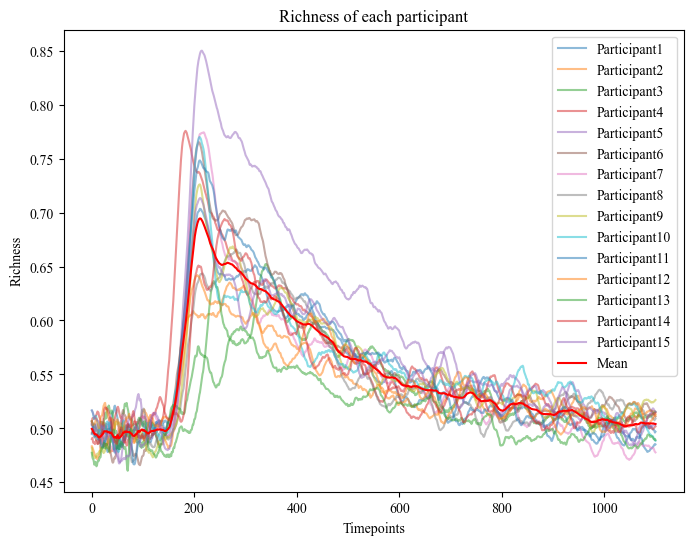

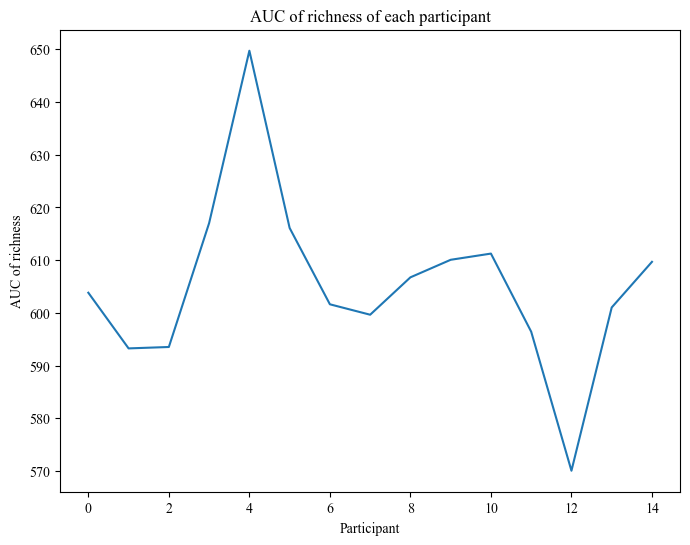

In [19]:
def get_richness(rdms):

    p_richness = []

    for p in range(rdms.shape[0]):

        rdm = rdms[p, :, :, :]
        richness = np.mean(rdm, axis=(1, 2))
        p_richness.append(richness)

    avg_richness = np.mean(p_richness, axis=0)

    return np.array(p_richness), avg_richness


p_richness, avg_richness = get_richness(neural_rdms)


# plot richness of each participant
plt.figure(figsize=(8, 6))
for p in range(p_richness.shape[0]):
    plt.plot(p_richness[p], alpha=0.5, label=f'Participant{p+1}')
plt.plot(avg_richness, color='red', label='Mean')
plt.xlabel('Timepoints')
plt.ylabel('Richness')
plt.legend()
plt.title('Richness of each participant')
plt.show()


def calculate_auc_richness(p_richness):
    auc_richness = []
    for p in range(p_richness.shape[0]):
        auc_richness.append(calculate_auc(p_richness[p]))

    return auc_richness


auc_richness = calculate_auc_richness(p_richness)

# plot AUC of richness of each participant
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(auc_richness)), auc_richness)
plt.xlabel('Participant')
plt.ylabel('AUC of richness')
plt.title('AUC of richness of each participant')
plt.show()

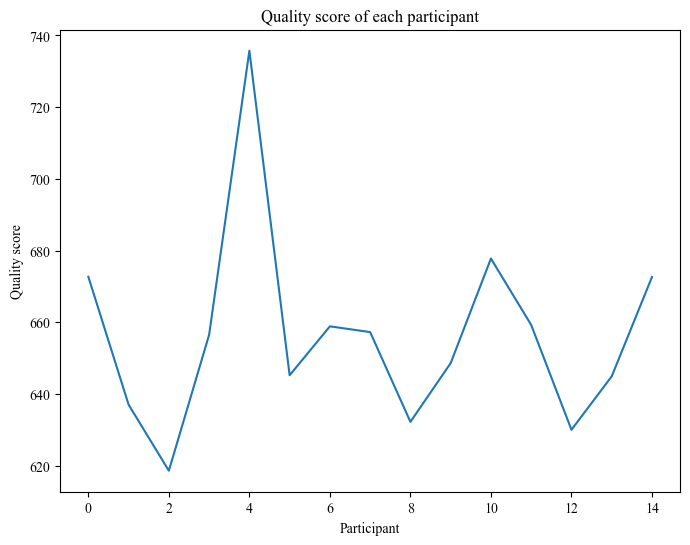

In [21]:
# quality score = AUC of richness * AUC of correlation

quality_score = np.array(auc_richness) + np.array(p_auc)

# plot quality score of each participant
plt.figure(figsize=(8, 6))
plt.plot(np.arange(len(quality_score)), quality_score)
plt.xlabel('Participant')
plt.ylabel('Quality score')
plt.title('Quality score of each participant')
plt.show()
